# NSGA-II Improved Smart (2026 version)



In [ ]:
%matplotlib inline
import math
import random
import time
from typing import Any, List, Optional

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.stats import cauchy, qmc
from tabulate import tabulate

from pymoo.problems import get_problem
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV

In [8]:
class ProblemWrapper:
    def __init__(self, prob: Any) -> None:
        self.n_var = prob.n_var
        self.n_obj = prob.n_obj
        self.xl    = prob.xl
        self.xu    = prob.xu
        self._prob = prob

    def evaluate(self, x: np.ndarray) -> np.ndarray:
        return self._prob.evaluate(x)


class CreationMode:
    INIT = "init"
    DE   = "de"
    SBX  = "sbx"
    OBL  = "obl"


class Individual:
    __slots__ = [
        "X", "F", "rank", "crowding_dist",
        "domination_count", "dominated_set",
        "creation_mode", "used_F", "used_CR",
    ]

    def __init__(self) -> None:
        self.X:                Optional[np.ndarray] = None
        self.F:                Optional[np.ndarray] = None
        self.rank:             Optional[int]        = None
        self.crowding_dist:    float                = 0.0
        self.domination_count: int                  = 0
        self.dominated_set:    List[int]            = []
        self.creation_mode:    str                  = CreationMode.INIT
        self.used_F:           float                = 0.5
        self.used_CR:          float                = 0.5

In [9]:
def fast_non_dominated_sort(population: List[Individual]) -> List[List[Individual]]:
    if not population:
        return []

    F = np.array([ind.F for ind in population])
    n = len(population)

    leq = (F[:, None, :] <= F[None, :, :]).all(axis=2)
    lt  = (F[:, None, :] <  F[None, :, :]).any(axis=2)
    dominates = leq & lt

    domination_count = dominates.sum(axis=0).astype(int)
    dominated_by     = [np.where(dominates[i])[0].tolist() for i in range(n)]

    current_front_indices = np.where(domination_count == 0)[0].tolist()
    if not current_front_indices:
        return []

    fronts: List[List[Individual]] = []
    rank = 1

    while current_front_indices:
        for idx in current_front_indices:
            population[idx].rank = rank
        fronts.append([population[idx] for idx in current_front_indices])

        next_front_indices = []
        for p in current_front_indices:
            for q in dominated_by[p]:
                domination_count[q] -= 1
                if domination_count[q] == 0:
                    next_front_indices.append(q)

        current_front_indices = next_front_indices
        rank += 1

    return fronts

def calculate_crowding_distance(front: List[Individual], n_obj: int) -> None:
    n = len(front)
    if n == 0:
        return
    for ind in front:
        ind.crowding_dist = 0.0

    for m in range(n_obj):
        front.sort(key=lambda ind: ind.F[m])
        front[0].crowding_dist  = float("inf")
        front[-1].crowding_dist = float("inf")

        f_range = front[-1].F[m] - front[0].F[m]
        if f_range == 0.0:
            continue

        for i in range(1, n - 1):
            if front[i].crowding_dist < float("inf"):
                front[i].crowding_dist += (front[i + 1].F[m] - front[i - 1].F[m]) / f_range

def remove_duplicates(population: List[Individual], epsilon: float = 1e-5) -> List[Individual]:
    if not population:
        return population
    F      = np.array([ind.F for ind in population])
    dists  = cdist(F, F)
    is_dup = np.zeros(len(population), dtype=bool)

    for i in range(len(population)):
        if is_dup[i]:
            continue
        duplicates_of_i          = np.where(dists[i, i + 1:] < epsilon)[0] + (i + 1)
        is_dup[duplicates_of_i]  = True

    return [ind for ind, dup in zip(population, is_dup) if not dup]

def environmental_selection(combined_pop: List[Individual], target_size: int, n_obj: int) -> List[Individual]:
    fronts  = fast_non_dominated_sort(combined_pop)
    new_pop: List[Individual] = []

    for front in fronts:
        calculate_crowding_distance(front, n_obj)
        slots_left = target_size - len(new_pop)

        if len(front) <= slots_left:
            new_pop.extend(front)
        else:
            front.sort(key=lambda ind: ind.crowding_dist, reverse=True)
            new_pop.extend(front[:slots_left])
            break

    new_pop.sort(key=lambda ind: (ind.rank, -ind.crowding_dist))
    return new_pop

In [10]:
def _sample_in_bounds(n: int, n_var: int, xl: np.ndarray, xu: np.ndarray, use_sobol: bool) -> np.ndarray:
    if use_sobol:
        n_rounded = 2 ** math.ceil(math.log2(max(n, 2)))
        raw = qmc.Sobol(d=n_var, scramble=True).random(n=n_rounded)[:n]
    else:
        raw = qmc.LatinHypercube(d=n_var).random(n=n)
    return qmc.scale(raw, xl, xu)

def _make_evaluated_individual(x: np.ndarray, f: np.ndarray) -> Individual:
    ind   = Individual()
    ind.X = x.copy()
    ind.F = f.flatten().copy()
    return ind

def initialize_obl(problem: ProblemWrapper, pop_size: int, use_gobl: bool = True, use_sobol: bool = True) -> List[Individual]:
    xl, xu = problem.xl, problem.xu
    x_primary = _sample_in_bounds(pop_size, problem.n_var, xl, xu, use_sobol)

    if use_gobl:
        k = np.random.uniform(0.0, 1.0, size=x_primary.shape)
        x_opposite = k * (xl + xu) - x_primary
    else:
        mid = (xl + xu) / 2.0
        r   = np.random.uniform(xl, mid, size=x_primary.shape)
        x_opposite = r + mid - x_primary

    x_all = np.clip(np.vstack([x_primary, x_opposite]), xl, xu)
    f_all = problem.evaluate(x_all)
    all_inds = [_make_evaluated_individual(x_all[i], f_all[i]) for i in range(len(x_all))]

    return environmental_selection(all_inds, target_size=pop_size, n_obj=problem.n_obj)

def initialize_from_data(problem: ProblemWrapper, initial_x: np.ndarray) -> List[Individual]:
    f_all = problem.evaluate(initial_x)
    return [_make_evaluated_individual(initial_x[i], f_all[i]) for i in range(len(initial_x))]

def get_neighborhood_indices(population: List[Individual], n_neighbors: int) -> np.ndarray:
    F      = np.array([ind.F for ind in population])
    f_min  = F.min(axis=0)
    f_max  = F.max(axis=0)
    spread = np.where(f_max - f_min == 0, 1e-10, f_max - f_min)
    F_norm = (F - f_min) / spread

    dists = cdist(F_norm, F_norm)
    k     = min(n_neighbors, len(population) - 1)
    return np.argpartition(dists, kth=k, axis=1)[:, :k]

def _neighborhood_mutant(target: Individual, neighbor_indices: np.ndarray, population: List[Individual], F: float) -> np.ndarray:
    neighbors = [population[i] for i in neighbor_indices]
    neighbors.sort(key=lambda ind: (ind.rank, -ind.crowding_dist))

    top_k   = max(1, int(len(neighbors) * 0.2))
    x_pbest = random.choice(neighbors[:top_k])

    pool   = [p for p in neighbors if p is not target] or population
    r1, r2 = random.sample(pool, 2) if len(pool) >= 2 else (pool[0], pool[0])

    return target.X + F * (x_pbest.X - target.X) + F * (r1.X - r2.X)

def _binomial_crossover(target_x: np.ndarray, mutant: np.ndarray, CR: float, n_var: int) -> np.ndarray:
    mask = np.random.rand(n_var) <= CR
    mask[np.random.randint(n_var)] = True
    return np.where(mask, mutant, target_x)

def de_mutation(target_idx: int, population: List[Individual], neighbor_indices: np.ndarray,
                xl: np.ndarray, xu: np.ndarray, n_var: int, mean_F: float, mean_CR: float) -> Individual:
    target     = population[target_idx]
    F          = float(np.clip(cauchy.rvs(loc=mean_F, scale=0.1), 0.1, 1.0))
    CR         = float(np.clip(np.random.normal(mean_CR, 0.1), 0.0, 1.0))
    use_global = np.random.rand() < 0.3

    if use_global:
        r1, r2, r3 = random.sample(population, 3)
        mutant = r1.X + F * (r2.X - r3.X)
    else:
        mutant = _neighborhood_mutant(target, neighbor_indices[target_idx], population, F)

    trial = _binomial_crossover(target.X, mutant, CR, n_var)

    child               = Individual()
    child.X             = np.clip(trial, xl, xu)
    child.creation_mode = CreationMode.DE
    child.used_F        = F
    child.used_CR       = CR
    return child

def _sbx_crossover(x1: np.ndarray, x2: np.ndarray, xl: np.ndarray, xu: np.ndarray, n_var: int, eta_c: float) -> np.ndarray:
    child = x1.copy()
    u         = np.random.rand(n_var)
    diff_mask = np.abs(x1 - x2) > 1e-14
    idx       = (u <= 0.5) & diff_mask

    if not np.any(idx):
        return child

    y1, y2 = np.minimum(x1[idx], x2[idx]), np.maximum(x1[idx], x2[idx])
    yl, yu = xl[idx], xu[idx]
    u_sbx  = np.random.rand(np.sum(idx))

    beta  = 1.0 + 2.0 * (y1 - yl) / (y2 - y1)
    alpha = 2.0 - beta ** (-(eta_c + 1.0))

    betaq      = np.empty_like(u_sbx)
    lo         = u_sbx <= 1.0 / alpha
    betaq[lo]  = (u_sbx[lo]  * alpha[lo])  ** (1.0 / (eta_c + 1.0))
    betaq[~lo] = (1.0 / (2.0 - u_sbx[~lo] * alpha[~lo])) ** (1.0 / (eta_c + 1.0))

    child[idx] = np.clip(0.5 * (y1 + y2 - betaq * (y2 - y1)), yl, yu)
    return child

def _polynomial_mutation(x: np.ndarray, xl: np.ndarray, xu: np.ndarray, n_var: int, pm: float, eta_m: float) -> np.ndarray:
    mutated  = x.copy()
    mut_mask = np.random.rand(n_var) <= pm
    if not np.any(mut_mask):
        return mutated

    y       = x[mut_mask]
    yl, yu  = xl[mut_mask], xu[mut_mask]
    delta1  = (y - yl) / (yu - yl)
    delta2  = (yu - y) / (yu - yl)
    mut_pow = 1.0 / (eta_m + 1.0)
    u       = np.random.rand(len(y))
    deltaq  = np.empty_like(y)

    lo = u <= 0.5
    if np.any(lo):
        val        = 2.0 * u[lo] + (1.0 - 2.0 * u[lo]) * (1.0 - delta1[lo]) ** (eta_m + 1.0)
        deltaq[lo] = val ** mut_pow - 1.0

    hi = ~lo
    if np.any(hi):
        val        = 2.0 * (1.0 - u[hi]) + 2.0 * (u[hi] - 0.5) * (1.0 - delta2[hi]) ** (eta_m + 1.0)
        deltaq[hi] = 1.0 - val ** mut_pow

    mutated[mut_mask] = np.clip(y + deltaq * (yu - yl), yl, yu)
    return mutated

def sbx_crossover_mutation(p1: Individual, p2: Individual, xl: np.ndarray, xu: np.ndarray,
                           n_var: int, pc: float, pm: float, eta_c: float, eta_m: float) -> Individual:
    child   = Individual()
    child.X = p1.X.copy()
    if np.random.rand() <= pc:
        child.X = _sbx_crossover(p1.X, p2.X, xl, xu, n_var, eta_c)

    child.X             = _polynomial_mutation(child.X, xl, xu, n_var, pm, eta_m)
    child.creation_mode = CreationMode.SBX
    return child

def generate_obl_offspring(population: List[Individual], problem: ProblemWrapper, xl: np.ndarray, xu: np.ndarray, jump_rate: float = 0.2) -> List[Individual]:
    X_matrix = np.array([ind.X for ind in population])
    pop_min  = X_matrix.min(axis=0)
    pop_max  = X_matrix.max(axis=0)

    reflected_x = []
    for ind in population:
        if random.random() < jump_rate:
            use_dynamic = random.random() < 0.5
            x_reflected = (pop_min + pop_max - ind.X) if use_dynamic else (xl + xu - ind.X)
            reflected_x.append(np.clip(x_reflected, xl, xu))

    if not reflected_x:
        return []

    x_batch = np.array(reflected_x)
    f_batch = problem.evaluate(x_batch)

    obl_inds = [_make_evaluated_individual(x_batch[i], f_batch[i]) for i in range(len(reflected_x))]
    for ind in obl_inds:
        ind.creation_mode = CreationMode.OBL
    return obl_inds

def tournament_selection(population: List[Individual]) -> Individual:
    p1, p2 = random.sample(population, 2)
    if p1.rank != p2.rank:
        return p1 if p1.rank < p2.rank else p2
    return p1 if p1.crowding_dist >= p2.crowding_dist else p2

In [11]:
class NSGA2ImprovedSmart:
    def __init__(self, problem: ProblemWrapper, pop_size: int = 100, n_gen: int = 100) -> None:
        self.problem  = problem
        self.pop_size = pop_size
        self.n_gen    = n_gen
        self.n_var    = problem.n_var
        self.n_obj    = problem.n_obj
        self.xl       = problem.xl
        self.xu       = problem.xu

        self.mean_F  = 0.5
        self.mean_CR = 0.5
        self.prob_de = 0.5

        min_neighbors = 10 if self.n_obj >= 3 else 5
        self.n_neighbors = max(min_neighbors, int(pop_size * 0.15))

        self.pc    = 0.9
        self.pm    = 1.0 / (self.n_var * np.log(max(pop_size, 2)))
        self.eta_c = 20.0
        self.eta_m = 20.0

        self.stagnation_patience   = n_gen // 4
        self.stagnation_tolerance  = 1e-4
        self.restart_elite_ratio   = 0.3

        self.population: List[Individual] = []
        self.history:    List[np.ndarray] = []

    def run(self, initial_x: Optional[np.ndarray] = None) -> np.ndarray:
        if initial_x is not None:
            pop = initialize_from_data(self.problem, initial_x)
            self.population = environmental_selection(pop, self.pop_size, self.n_obj)
        else:
            self.population = initialize_obl(self.problem, self.pop_size)
            
        self.history.clear()
        last_ideal = None
        stagnation_counter = 0

        for gen in range(self.n_gen):
            current_ideal = np.min([ind.F for ind in self.population], axis=0)

            if last_ideal is not None:
                improved = np.linalg.norm(current_ideal - last_ideal) >= self.stagnation_tolerance
                stagnation_counter = 0 if improved else stagnation_counter + 1

            if stagnation_counter >= self.stagnation_patience:
                self._partial_restart()
                stagnation_counter = 0
                current_ideal = np.min([ind.F for ind in self.population], axis=0)
            
            last_ideal = current_ideal
            neighbor_indices = get_neighborhood_indices(self.population, self.n_neighbors)

            offspring = []
            for i in range(self.pop_size):
                if np.random.rand() < self.prob_de:
                    child = de_mutation(i, self.population, neighbor_indices, self.xl, self.xu, self.n_var, self.mean_F, self.mean_CR)
                else:
                    child = sbx_crossover_mutation(tournament_selection(self.population), tournament_selection(self.population),
                                                   self.xl, self.xu, self.n_var, self.pc, self.pm, self.eta_c, self.eta_m)
                offspring.append(child)

            if gen % 10 == 0:
                offspring += generate_obl_offspring(self.population, self.problem, self.xl, self.xu)

            unevaluated = [ind for ind in offspring if ind.F is None]
            if unevaluated:
                x_batch = np.array([ind.X for ind in unevaluated])
                f_batch = self.problem.evaluate(x_batch)
                for ind, f in zip(unevaluated, f_batch):
                    ind.F = f.flatten().copy()

            combined = remove_duplicates(self.population + offspring)
            
            missing = self.pop_size - len(combined)
            if missing > 0:
                x_fill = self.xl + np.random.rand(missing, self.n_var) * (self.xu - self.xl)
                f_fill = self.problem.evaluate(x_fill)
                extras = [_make_evaluated_individual(x_fill[i], f_fill[i]) for i in range(missing)]
                combined += extras

            self.population = environmental_selection(combined, self.pop_size, self.n_obj)
            self._update_adaptive_parameters(offspring)
            self.history.append(np.array([ind.F for ind in self.population]))

        return np.array([ind.F for ind in self.population])

    def _partial_restart(self) -> None:
        n_keep   = int(self.pop_size * self.restart_elite_ratio)
        elite    = self.population[:n_keep]
        n_new    = self.pop_size - n_keep
        x_new    = self.xl + np.random.rand(n_new, self.n_var) * (self.xu - self.xl)
        f_new    = self.problem.evaluate(x_new)
        new_inds = [_make_evaluated_individual(x_new[i], f_new[i]) for i in range(n_new)]

        self.population = environmental_selection(elite + new_inds, self.pop_size, self.n_obj)
        self.mean_F = self.mean_CR = 0.5

    def _update_adaptive_parameters(self, offspring: List[Individual]) -> None:
        de_offspring  = [ind for ind in offspring if ind.creation_mode == CreationMode.DE]
        sbx_offspring = [ind for ind in offspring if ind.creation_mode == CreationMode.SBX]
        successful_de = [ind for ind in de_offspring if ind.rank == 1]

        total = len(de_offspring) + len(sbx_offspring)
        if total > 0:
            de_ratio     = len(de_offspring) / total
            self.prob_de = float(np.clip(0.9 * self.prob_de + 0.1 * de_ratio, 0.2, 0.8))

        if successful_de:
            f_values     = np.array([ind.used_F  for ind in successful_de])
            cr_values    = np.array([ind.used_CR for ind in successful_de])
            lehmer_mean_F = float(np.mean(f_values ** 2) / np.mean(f_values)) if np.mean(f_values) != 0 else 0.5
            self.mean_F  = 0.9 * self.mean_F  + 0.1 * lehmer_mean_F
            self.mean_CR = 0.9 * self.mean_CR + 0.1 * float(np.mean(cr_values))


Đang chạy ZDT1 (10 lần)... Xong!

Đang chạy ZDT2 (10 lần)... Xong!

Đang chạy ZDT3 (10 lần)... Xong!

Đang chạy ZDT4 (10 lần)... Xong!

Đang chạy ZDT6 (10 lần)... Xong!

                                KẾT QUẢ TỔNG HỢP (10 RUNS)                                
╒═══════════╤══════════════════╤════════════════════╤════════════════════╤════════════╕
│ Problem   │ Algorithm        │ IGD (Mean ± Std)   │ HV (Mean ± Std)    │   Time (s) │
╞═══════════╪══════════════════╪════════════════════╪════════════════════╪════════════╡
│ ZDT1      │ Improved NSGA-II │ 0.00449 (±0.00026) │ 0.87096 (±0.00018) │    3.15000 │
├───────────┼──────────────────┼────────────────────┼────────────────────┼────────────┤
│ ZDT2      │ Improved NSGA-II │ 0.00483 (±0.00028) │ 0.53756 (±0.00043) │    1.83000 │
├───────────┼──────────────────┼────────────────────┼────────────────────┼────────────┤
│ ZDT3      │ Improved NSGA-II │ 0.00690 (±0.00349) │ 1.02218 (±0.00318) │    2.06000 │
├───────────┼──────────────────┼──

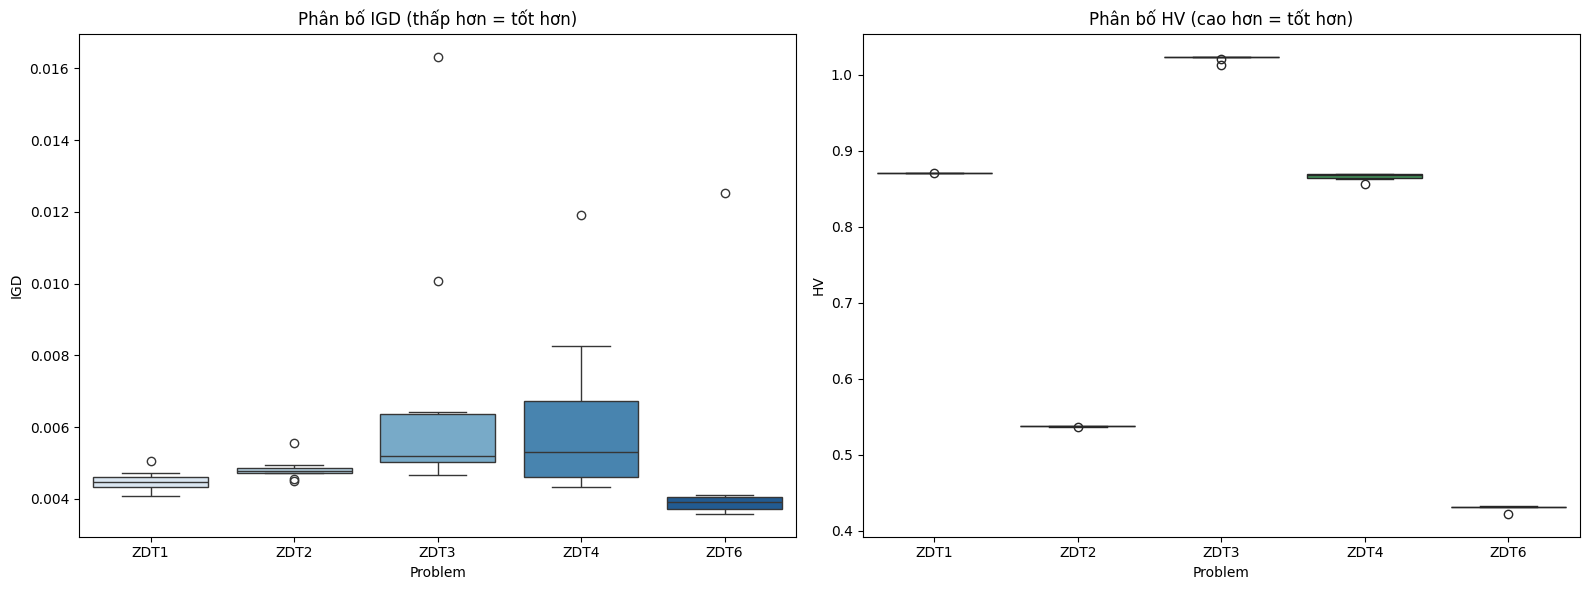

In [16]:
problems = ['zdt1', 'zdt2', 'zdt3', 'zdt4', 'zdt6']
N_RUNS = 10
N_GEN = 200
POP_SIZE = 100
final_results_summary = []
all_raw_data = pd.DataFrame()

for p_name in problems:
    print(f"\nĐang chạy {p_name.upper()} ({N_RUNS} lần)... ", end="")
    prob = get_problem(p_name)
    wrapper = ProblemWrapper(prob)

    igd_vals, hv_vals, times = [], [], []
    ref_front = prob.pareto_front() 

    ref_point = np.max(ref_front, axis=0) * 1.1 

    for run in range(1, N_RUNS+1):
        start = time.time()
        algo = NSGA2ImprovedSmart(wrapper, pop_size=POP_SIZE, n_gen=N_GEN)
        F = algo.run()
        t = time.time() - start

        igd = IGD(ref_front).do(F)
        hv = HV(ref_point=ref_point).do(F)

        igd_vals.append(igd)
        hv_vals.append(hv)
        times.append(t)

        temp_df = pd.DataFrame({
            'Problem': p_name.upper(),
            'Run': run,
            'IGD': igd,
            'HV': hv,
            'Time (s)': t
        }, index=[0])
        all_raw_data = pd.concat([all_raw_data, temp_df], ignore_index=True)

    mean_igd, std_igd = np.mean(igd_vals), np.std(igd_vals)
    mean_hv,  std_hv  = np.mean(hv_vals),  np.std(hv_vals)
    mean_time = np.mean(times)

    final_results_summary.append({
        'Problem': p_name.upper(),
        'Algorithm': 'Improved NSGA-II',
        'IGD (Mean ± Std)': f'{mean_igd:.5f} (±{std_igd:.5f})',
        'HV (Mean ± Std)': f'{mean_hv:.5f} (±{std_hv:.5f})',
        'Time (s)': f'{mean_time:.2f}'
    })
    print('Xong!')

# --- Hiển thị kết quả ---
df_summary = pd.DataFrame(final_results_summary)
print('\n' + '='*90)
print(f'KẾT QUẢ TỔNG HỢP ({N_RUNS} RUNS)'.center(90))
print('='*90)
print(tabulate(df_summary, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt='.5f'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=all_raw_data, x='Problem', y='IGD', ax=axes[0], palette='Blues', hue='Problem', legend=False)
axes[0].set_title('Phân bố IGD (thấp hơn = tốt hơn)')
sns.boxplot(data=all_raw_data, x='Problem', y='HV',  ax=axes[1], palette='Greens', hue='Problem', legend=False)
axes[1].set_title('Phân bố HV (cao hơn = tốt hơn)')
plt.tight_layout()
plt.show()